In [1]:
import numpy as np
from pygmid import Lookup as lk
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import scipy.constants as sc

# Load technology data
NCH = lk('../../sky130_lookup/simulation/nfet_01v8.mat')
PCH = lk('../../sky130_lookup/simulation/pfet_01v8.mat')

In [2]:
# Check the range of the lookup axes
print(f"VGS range: {NCH['VGS']}")
print(f"VDS range: {NCH['VDS']}")
print(f"VSB range: {NCH['VSB']}")
print(f"Lengths (L) available: {NCH['L']}")

# Check the shape of the ID (Current) matrix
print(f"ID Matrix Shape: {NCH['ID'].shape}")

VGS range: [0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.    1.025 1.05  1.075 1.1   1.125 1.15  1.175
 1.2   1.225 1.25  1.275 1.3   1.325 1.35  1.375 1.4   1.425 1.45  1.475
 1.5   1.525 1.55  1.575 1.6   1.625 1.65  1.675 1.7   1.725 1.75  1.775
 1.8  ]
VDS range: [0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.    1.025 1.05  1.075 1.1   1.125 1.15  1.175
 1.2   1.225 1.25  1.275 1.3   1.325 1.35  1.375 1.4   1.425 1.45  1.475
 1.5   1.525 1.55  1.575 1.6   1.625 1.65  1.675 1.7   1.725 1.75  1.775
 1.8  ]
VSB range: [-0.   0.2  0.4]
Lengths (L) available: [0.15 0.16 0.17 0.18 0.19 0.2  0.3 

In [3]:
# Check the range of the lookup axes
print(f"VGS range: {PCH['VGS']}")
print(f"VDS range: {PCH['VDS']}")
print(f"VSB range: {PCH['VSB']}")
print(f"Lengths (L) available: {PCH['L']}")

# Check the shape of the ID (Current) matrix
print(f"ID Matrix Shape: {PCH['ID'].shape}")

VGS range: [0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.    1.025 1.05  1.075 1.1   1.125 1.15  1.175
 1.2   1.225 1.25  1.275 1.3   1.325 1.35  1.375 1.4   1.425 1.45  1.475
 1.5   1.525 1.55  1.575 1.6   1.625 1.65  1.675 1.7   1.725 1.75  1.775
 1.8  ]
VDS range: [0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.    1.025 1.05  1.075 1.1   1.125 1.15  1.175
 1.2   1.225 1.25  1.275 1.3   1.325 1.35  1.375 1.4   1.425 1.45  1.475
 1.5   1.525 1.55  1.575 1.6   1.625 1.65  1.675 1.7   1.725 1.75  1.775
 1.8  ]
VSB range: [-0.   0.2  0.4]
Lengths (L) available: [0.15 0.16 0.17 0.18 0.19 0.2  0.3 

In [4]:
# =================
# FDDA DESIGN SPECS
# =================
VDD = 1.8                                 # Supply Voltage (V)
CL  = 1e-12                               # Load Capacitance (F)
Vicm_spec = (0.8, 1.0)                    # Input Common Mode Range (V)
Gain_dc_spec_dB = 72                      # DC Gain (dB)
GBW_spec = 48e6                           # Gain Bandwidth (Hz)
PM_spec = 56                              # Phase Margin (degrees)
SR_spec = 6.6e6                           # Slew Rate (V/s)
CMRR_spec_dB = 120                        # Common Mode Rejection Ratio (dB)
PSRR_spec_dB = 68                         # Power Supply Rejection Ratio (dB)
noise_spec = 0.27e-6                      # Input Referred Noise (V/√Hz)
Power_spec = 180e-6                       # Power Consumption (W)
Area_spec = 42800e-12                     # Area (m^2)

Gain_dc_spec = 10**(Gain_dc_spec_dB/20)   # Convert dB to V/V
CMRR_spec = 10**(CMRR_spec_dB/20)         # Convert dB to V/V
PSRR_spec = 10**(PSRR_spec_dB/20)         # Convert dB to V/V

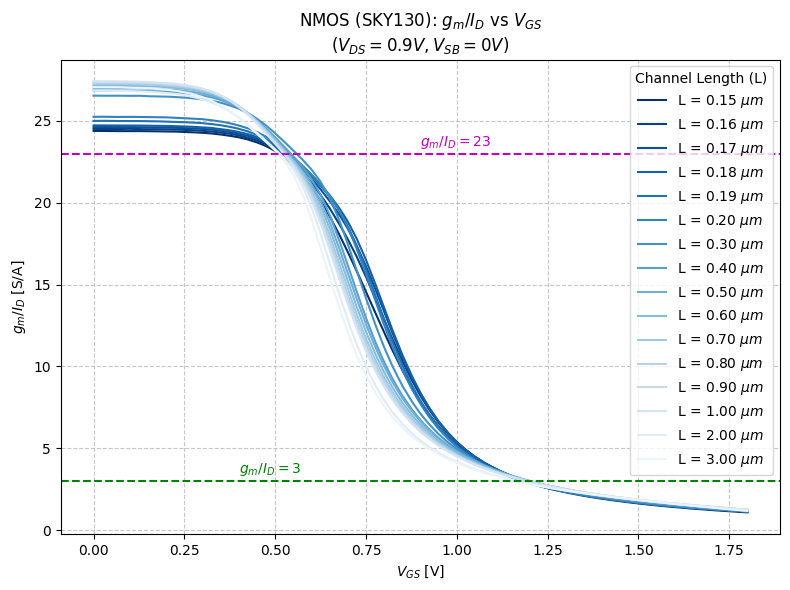

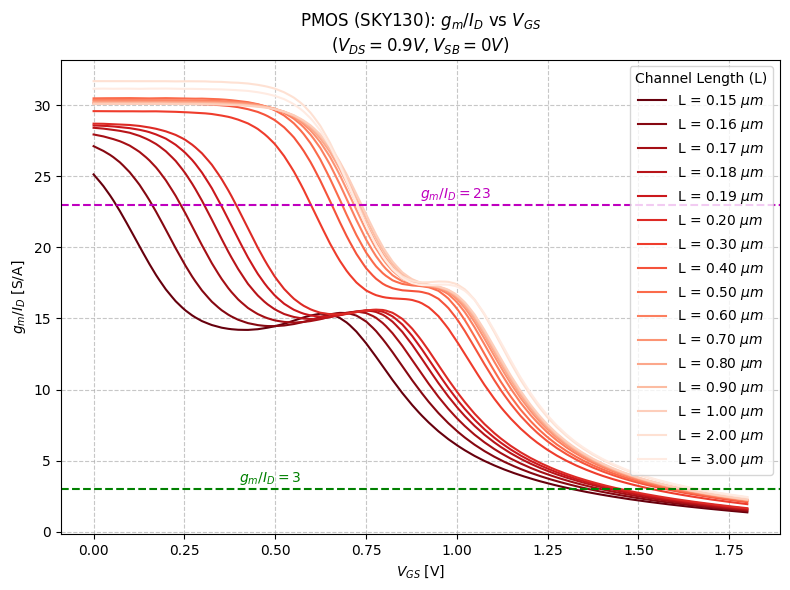

In [5]:
# ==============================
# NMOS & PMOS gm/ID VS VGS PLOTS
# ==============================
# Define Sweep Parameters
VGS_sweep = np.linspace(0, VDD, 200) 
VDS_const = VDD/2  # Set VDS to mid-rail
VSB_const = 0  # Source-Bulk voltage

# Plotting Function
def plot_gmid_vs_vgs(device_data, device_name, color_map):
    plt.figure(figsize=(8, 6))
    
    # Extract all available Lengths from the LUT
    L_values = np.unique(device_data['L'])

    # Loop through each 'L' and plot
    for i, L_val in enumerate(L_values):
        # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
        gm_ID = device_data.lookup('GM_ID', vgs=VGS_sweep, VDS=VDS_const, VSB=VSB_const, L=L_val)
        
        # Plotting
        plt.plot(VGS_sweep, gm_ID, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

    # Formatting the Plot
    plt.title(f'{device_name}: $g_m/I_D$ vs $V_{{GS}}$\n($V_{{DS}}={VDS_const}V, V_{{SB}}={VSB_const}V$)')
    plt.xlabel('$V_{GS}$ [V]')
    plt.ylabel('$g_m/I_D$ [S/A]')

    # Upper bound for gm/ID axis
    plt.axhline(y=23, color='m', linestyle='--')
    plt.text(0.9, 23.5, '$g_m/I_D = 23$', color='m')
    # Lower bound for gm/ID axis
    plt.axhline(y=3, color='g', linestyle='--')
    plt.text(0.4, 3.5, '$g_m/I_D = 3$', color='g')

    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper right', title="Channel Length (L)")
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_gmid_vs_vgs(NCH, "NMOS (SKY130)", plt.cm.Blues_r)
plot_gmid_vs_vgs(PCH, "PMOS (SKY130)", plt.cm.Reds_r)

In [6]:
# ==================================
# FDDA REFERENCE SIMULATION READINGS
# ==================================
V_B1 = 0.77600       # V
V_B2 = 0.66566       # V
V_B3 = 0.89881       # V
V_B4 = 0.57924       # V
V_CMFB = 0.76174     # V

V_A = 1.59950        # V
V_B = 0.24871        # V
V_C = 1.17100        # V
Vout_DC = 0.99599    # V

I_T = 22.125e-6      # A
I_X = 4.1591e-6      # A

gm_ID_1 = 17.14696   # S/A
gm_ID_2 = 17.85320   # S/A
gm_ID_3 = 18.03487   # S/A
gm_ID_4 = 19.70470   # S/A
gm_ID_5 = 15.95002   # S/A
gm_ID_6 = 16.66659   # S/A

In [7]:
# =======================================
# INPUT DESIGN PARAMETERS FOR FDDA SIZING
# =======================================
# gm_ID_1 = 20   # S/A
# gm_ID_2 = 20   # S/A
# gm_ID_3 = 20   # S/A
# gm_ID_4 = 20   # S/A
# gm_ID_5 = 20   # S/A
# gm_ID_6 = 20   # S/A

L_1 = 1        # um
L_2 = 1        # um
L_3 = 1        # um
L_4 = 1        # um
L_5 = 1        # um
L_6 = 1        # um

# I_T = 20e-3    # A
# I_X = 20e-3    # A

# V_A = 1.4      # V
# V_B = 0.4      # V
# V_C = 1.4      # V
# Vout_DC = 0.9  # V

Vds_1 = V_C - V_B
Vds_2 = VDD - V_A
Vds_3 = V_A - Vout_DC
Vds_4 = Vout_DC - V_B
Vds_5 = V_B
Vds_6 = VDD - V_C

freq = 1e3        # Frequency at which CMRR, PSRR, and noise is calculated (Hz)
temp = 298        # Temperature (K)
k = sc.Boltzmann  # Boltzmann's constant (J/K)

In [8]:
# ================
# GAIN CALCULATION
# ================
gm_2 = gm_ID_2 * I_X
gm_3 = gm_ID_3 * I_X
gds_2 = gm_2 / PCH.lookup('GM_GDS', GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
gds_3 = gm_3 / PCH.lookup('GM_GDS', GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
Rout_A = (1 / gds_3) + (1 / gds_2) + (gm_3 * (1 / gds_3) * (1 / gds_2))
print(f"Rout_A: {Rout_A/1e6:.2f} MΩ")

gm_4 = gm_ID_4 * I_X
gm_5 = gm_ID_5 * (I_X + I_T)
gm_1 = gm_ID_1 * (I_T / 2)
gds_4 = gm_4 / NCH.lookup('GM_GDS', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
gds_5 = gm_5 / NCH.lookup('GM_GDS', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
gds_1 = gm_1 / PCH.lookup('GM_GDS', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
Rparr_dm = 1 / (gds_5 + (2 * gds_1))
Rout_B_dm = (1 / gds_4) + Rparr_dm + (gm_4 * (1 / gds_4) * Rparr_dm)
print(f"Rout_B_dm: {Rout_B_dm/1e6:.2f} MΩ")

Gm_dm = gm_1
print(f"Gm_dm: {Gm_dm*1e6:.2f} µS")

Rout_dm = (Rout_A * Rout_B_dm) / (Rout_A + Rout_B_dm)
print(f"Rout_dm: {Rout_dm/1e6:.2f} MΩ")

Gain_dc_calc = Gm_dm * Rout_dm
print(f"Gain_dc_calc_dB: {20*np.log10(Gain_dc_calc):.2f} dB")

Rout_A: 658.23 MΩ
Rout_B_dm: 26.58 MΩ
Gm_dm: 189.69 µS
Rout_dm: 25.55 MΩ
Gain_dc_calc_dB: 73.71 dB


In [9]:
# ================================
# OUTPUT VOLTAGE SWING CALCULATION
# ================================
Vgs_4 = NCH.lookupVGS(GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
Vth_4 = NCH.lookup('VT', VGS=Vgs_4, VDS=Vds_4, VSB=0, L=L_4)
Vov_4 = Vgs_4 - Vth_4
Vgs_5 = NCH.lookupVGS(GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
Vth_5 = NCH.lookup('VT', VGS=Vgs_5, VDS=Vds_5, VSB=0, L=L_5)
Vov_5 = Vgs_5 - Vth_5
V_OP_min = abs(Vov_4) + abs(Vov_5)
print(f"V_OP_min: {V_OP_min:.2f} V")

Vgs_3 = PCH.lookupVGS(GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
Vth_3 = PCH.lookup('VT', VGS=Vgs_3, VDS=Vds_3, VSB=0, L=L_3)
Vov_3 = Vgs_3 - Vth_3
Vgs_2 = PCH.lookupVGS(GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
Vth_2 = PCH.lookup('VT', VGS=Vgs_2, VDS=Vds_2, VSB=0, L=L_2)
Vov_2 = Vgs_2 - Vth_2
V_OP_max = VDD - abs(Vov_3) - abs(Vov_2)
print(f"V_OP_max: {V_OP_max:.2f} V")

V_OP_swing = V_OP_max - V_OP_min
print(f"V_OP_swing: {V_OP_swing:.2f} V")
Vout_swing_calc = 2 * V_OP_swing
print(f"Vout_swing_calc: {Vout_swing_calc:.2f} V")

V_OP_min: 0.10 V
V_OP_max: 1.49 V
V_OP_swing: 1.39 V
Vout_swing_calc: 2.77 V


In [10]:
# ==================================
# GAIN-BANDWIDTH PRODUCT CALCULATION
# ==================================
Cdd_3 = gm_3 / PCH.lookup('GM_CDD', GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
Cdd_4 = gm_4 / NCH.lookup('GM_CDD', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
C_load = (2 * CL) + Cdd_3 + Cdd_4
print(f"C_load: {C_load*1e15:.2f} fF")

GBW_rads = Gm_dm / C_load
GBW_calc = GBW_rads / (2 * np.pi)
print(f"GBW_calc: {GBW_calc/1e6:.2f} MHz")

C_load: 2225.12 fF
GBW_calc: 13.57 MHz


In [11]:
# ========================
# PHASE MARGIN CALCULATION
# ========================
Rfold = 1 / (gm_4 + gds_5 + (2 * gds_1))
print(f"Rfold: {Rfold/1e3:.2f} kΩ")

Css_4 = gm_4 / NCH.lookup('GM_CSS', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
Cdd_1 = gm_1 / PCH.lookup('GM_CDD', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
Cdd_5 = gm_5 / NCH.lookup('GM_CDD', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
Cfold = Css_4 + Cdd_5 + (2 * Cdd_1)
print(f"Cfold: {Cfold*1e15:.2f} fF")

non_dom_pole = 1 / (Rfold * Cfold)
print(f"Non-dominant Pole: {non_dom_pole/(2 * np.pi * 1e6):.2f} MHz")

PM_calc = 90 - (np.arctan(GBW_rads / non_dom_pole) * (180 / np.pi))
print(f"PM_calc: {PM_calc:.2f} degrees")

Rfold: 11.32 kΩ
Cfold: 229.71 fF
Non-dominant Pole: 61.23 MHz
PM_calc: 77.51 degrees


In [12]:
# =====================
# SLEW RATE CALCULATION
# =====================
SR_calc = I_T / C_load
print(f"SR_calc: {SR_calc/1e6:.2f} V/µs")

SR_calc: 9.94 V/µs


In [13]:
# =================
# POWER CALCULATION
# =================
Power_calc = 4 * (I_X + I_T) * VDD
print(f"Power_calc: {Power_calc*1e6:.2f} µW")

Power_calc: 189.25 µW


In [14]:
# ===================================
# INPUT COMMON MODE RANGE CALCULATION
# ===================================
Vgs_1 = PCH.lookupVGS(GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
Vth_1 = PCH.lookup('VT', VGS=Vgs_1, VDS=Vds_1, VSB=0, L=L_1)
Vicm_min = V_B - abs(Vth_1)
print(f"Vicm_min: {Vicm_min:.2f} V")

Vgs_6 = PCH.lookupVGS(GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)
Vth_6 = PCH.lookup('VT', VGS=Vgs_6, VDS=Vds_6, VSB=0, L=L_6)
Vov_6 = Vgs_6 - Vth_6
Vicm_max = VDD - Vgs_1 - abs(Vov_6)
print(f"Vicm_max: {Vicm_max:.2f} V")

Vicm_min: -0.77 V
Vicm_max: 0.81 V


In [15]:
# ================
# CMRR CALCULATION
# ================
gm_6 = gm_ID_6 * I_T
gds_6 = gm_6 / PCH.lookup('GM_GDS', GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)
Cdd_6 = gm_6 / PCH.lookup('GM_CDD', GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)
Css_1 = gm_1 / PCH.lookup('GM_CSS', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
C_tail = Cdd_6 + (2 * Css_1)
Z_tail = np.abs(1 / (gds_6 + (1j * 2 * np.pi * freq * C_tail)))
print(f"Z_tail: {Z_tail/1e6:.2f} MΩ")

Gm_cm = 1 / Z_tail
print(f"Gm_cm: {Gm_cm*1e6:.2f} µS")

Rparr_cm = 1 / (gds_5 + (1 / ((0.5 / gds_1) + ((1 / gds_6) * (1 + (gm_1 / gds_1))))))
Rout_B_cm = (1 / gds_4) + ((1 + (gm_4 / gds_4)) * Rparr_cm)
Rout_cm = (Rout_A * Rout_B_cm) / (Rout_A + Rout_B_cm)
Zout_cm = abs(1 / ((1 / Rout_cm) + (1j * 2 * np.pi * freq * C_load)))
print(f"Zout_cm: {Zout_cm/1e6:.2f} MΩ")

Gain_cm_open = Gm_cm * Zout_cm
print(f"Gain_cm_open_dB: {20*np.log10(Gain_cm_open):.2f} dB")

###################################
Lgain_cmfb = abs((gm_2 * gm_4) / ((1j * 2 * np.pi * freq * C_load) * gm_2)) # Change gm values later (dummies used)
###################################
Gain_cm_calc = Gain_cm_open / (1 + Lgain_cmfb)
print(f"Gain_cm_calc_dB: {20*np.log10(Gain_cm_calc):.2f} dB")

Zout_dm = abs(1 / ((1 / Rout_dm) + (1j * 2 * np.pi * freq * C_load)))
Gain_dm_calc = Gm_dm * Zout_dm
print(f"Gain_dm_calc_dB: {20*np.log10(Gain_dm_calc):.2f} dB")

CMRR_calc = Gain_dm_calc / Gain_cm_calc
print(f"CMRR_calc_dB: {20*np.log10(CMRR_calc):.2f} dB")

Z_tail: 1.11 MΩ
Gm_cm: 0.90 µS
Zout_cm: 26.36 MΩ
Gain_cm_open_dB: 27.49 dB
Gain_cm_calc_dB: -47.87 dB
Gain_dm_calc_dB: 73.19 dB
CMRR_calc_dB: 121.06 dB


In [16]:
# ================================
# INPUT REFERRED NOISE CALCULATION
# ================================
gamma_1 = PCH.gamma(GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
noise_1 = 4 * (((4 * k * temp * gamma_1) / gm_1) + (PCH.lookup('SFL_GM', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1) / gm_1 / freq))
print(f"noise_1: {np.sqrt(noise_1)*1e6:.2f} µV/√Hz")

gamma_5 = NCH.gamma(GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
noise_5 = 2 * (((4 * k * temp * gamma_5 * gm_5) / (gm_1 ** 2)) + ((NCH.lookup('SFL_GM', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5) / freq) * (gm_5 / (gm_1 ** 2))))
print(f"noise_5: {np.sqrt(noise_5)*1e6:.2f} µV/√Hz")

gamma_2 = PCH.gamma(GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
noise_2 = 2 * (((4 * k * temp * gamma_2 * gm_2) / (gm_1 ** 2)) + ((PCH.lookup('SFL_GM', GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2) / freq) * (gm_2 / (gm_1 ** 2))))
print(f"noise_2: {np.sqrt(noise_2)*1e6:.2f} µV/√Hz")

noise_calc = np.sqrt(noise_1 + noise_5 + noise_2)
print(f"noise_calc: {noise_calc*1e6:.3f} µV/√Hz")

noise_1: 0.07 µV/√Hz
noise_5: 0.33 µV/√Hz
noise_2: 0.02 µV/√Hz
noise_calc: 0.338 µV/√Hz


In [17]:
# # ================
# # PSRR CALCULATION
# # ================
# gm_mirr = (gm_4 / (gm_4 + gds_5)) * (gm_6 + (((2 * gm_1) - gm_6 + (2 * gds_1)) / (1 + (2 * gm_1 / gds_6) + (2 * gds_1))))
# gm_dir = gm_2 + ((gm_3 - gm_2) / (1 + (gm_3 / gds_2)))
# Gm_ps = gm_mirr + gm_dir
# print(f"Gm_ps: {Gm_ps*1e6:.2f} µS")

# Gain_ps_calc = Gm_ps * Zout_cm
# print(f"Gain_ps_calc_dB: {20*np.log10(Gain_ps_calc):.2f} dB")

# PSRR_calc = Gain_dm_calc / Gain_ps_calc
# print(f"PSRR_calc_dB: {20*np.log10(PSRR_calc):.2f} dB")

In [18]:
# =====================================
# CALCUATE W SIZING FOR EACH TRANSISTOR
# =====================================
JD_1 = PCH.lookup('ID_W', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
JD_3 = PCH.lookup('ID_W', GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
JD_4 = NCH.lookup('ID_W', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
JD_5 = NCH.lookup('ID_W', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
JD_6 = PCH.lookup('ID_W', GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)

W_1 = (I_T / 2) / JD_1
W_2 = I_X / JD_2
W_3 = I_X / JD_3
W_4 = I_X / JD_4
W_5 = (I_X + I_T) / JD_5
W_6 = I_T / JD_6

print(f"W_1: {W_1:.2f} µm")
print(f"W_2: {W_2:.2f} µm") 
print(f"W_3: {W_3:.2f} µm")
print(f"W_4: {W_4:.2f} µm")
print(f"W_5: {W_5:.2f} µm")
print(f"W_6: {W_6:.2f} µm")

W_1: 182.69 µm
W_2: 361.47 µm
W_3: 426.45 µm
W_4: 9.54 µm
W_5: 21.98 µm
W_6: 198.08 µm


In [19]:
V_A = 1.5        # V
V_B = 0.3        # V
Vout_DC = 0.9    # V

I_T = 2.98e-6      # A

gm_ID = {
    'gm_ID_1': 19.36,   # S/A
    'gm_ID_2': 13.25,   # S/A
    'gm_ID_3': 12.37,   # S/A
    'gm_ID_4': 12.77,   # S/A
    'gm_ID_5': 12.53,   # S/A
    'gm_ID_6': 12.68    # S/A
}

L = {
    'L_1': 0.3,  # um
    'L_2': 0.5,  # um
    'L_3': 1,  # um
    'L_4': 3,  # um
    'L_5': 2,  # um
    'L_6': 0.7,  # um
}

In [20]:
def get_inputParams(gm_ID, L, V_B):

    # Get the Vgs value based on Bulk voltage
    Vgs_1 = PCH.lookupVGS(GM_ID=gm_ID, VDB=(VDD-V_B), VGB=(VDD-Vout_DC), L=L)

    # Calculate the intermediate node
    V_C = Vout_DC + Vgs_1
    if V_C < 0 or V_C > VDD:
        print("Error: Intermediate node voltage out of bounds. Check the initial conditions.")
        return None, None, None, None

    # Calculate the Vds and Vsb voltages
    Vds_1 = V_C - V_B
    Vsb_1 = VDD - V_C
    if Vds_1 <= 0 or Vsb_1 <= 0:
        print("Error: Vds or Vsb is out of bounds. Check the initial conditions.")
        return None, None, None, None

    return Vgs_1, Vds_1, Vsb_1, V_C

In [21]:
# Function to get parameters for each transistor based on gm_ID, L, and I_T
def get_params(gm_ID, L, I_T):

    # Get the initial Vgs, Vds, and intermediate node voltage (V_C) for M1
    Vgs_1, Vds_1, Vsb_1, V_C = get_inputParams(gm_ID['gm_ID_1'], L['L_1'], V_B)
    if Vgs_1 is None or Vds_1 is None or Vsb_1 is None or V_C is None:
        print("Error: Invalid operating point. Check the initial conditions and LUT values.")
        return None, None, None, None

    # Calculate Vds for all transistors based on the converged V_C and given node voltages
    Vds = {
        'Vds_1': Vds_1,
        'Vds_2': VDD - V_A,
        'Vds_3': V_A - Vout_DC,
        'Vds_4': Vout_DC - V_B,
        'Vds_5': V_B,
        'Vds_6': VDD - V_C
    }

    # Calculate Vsb for all transistors
    Vsb = {
        'Vsb_1': Vsb_1,
        'Vsb_2': 0,
        'Vsb_3': VDD - V_A,
        'Vsb_4': V_B,
        'Vsb_5': 0,
        'Vsb_6': 0,
        'Vsb_7': V_B,
        'Vsb_8': 0
    }

    # LUT readout for CMFB circuit transistors (M7 and M8)
    Vds['Vds_8'] = PCH.lookupVGS(GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], \
                                 VSB=Vsb['Vsb_2'], L=L['L_2'])  # Vgs_2 is equal to Vds_8 since M8 is diode-connected
    Vds['Vds_7'] = VDD - Vds['Vds_8'] - Vds['Vds_5']

    # Append gm_ID values for M7 and M8
    gm_ID['gm_ID_7'] = NCH.lookup('GM_ID', VGS=Vds['Vds_4'], VDS=Vds['Vds_7'], VSB=Vsb['Vsb_7'], L=L['L_4'])
    gm_ID['gm_ID_8'] = gm_ID['gm_ID_2']

    # Append L values for M7 and M8
    L['L_7'] = L['L_4']
    L['L_8'] = L['L_2']

    I_X = I_T / 4

    # Create a dictionary to hold the current density (A/µm) for each transistor
    ID = {
        'ID_1': I_T / 2,
        'ID_2': I_X,
        'ID_3': I_X,
        'ID_4': I_X,
        'ID_5': I_T + I_X,
        'ID_6': I_T,
        'ID_7': (I_T + I_X) / 2,
        'ID_8': I_T + I_X
    }

    # Read the gate-source voltage (V) from the LUTs
    Vgs = {
        'Vgs_1': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1']),
        'Vgs_2': Vds['Vds_8'],
        'Vgs_3': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=Vsb['Vsb_3'], L=L['L_3']),
        'Vgs_4': NCH.lookupVGS(GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=Vsb['Vsb_4'], L=L['L_4']),
        'Vgs_5': NCH.lookupVGS(GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=Vsb['Vsb_5'], L=L['L_5']),
        'Vgs_6': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=Vsb['Vsb_6'], L=L['L_6']),
        'Vgs_7': NCH.lookupVGS(GM_ID=gm_ID['gm_ID_7'], VDS=Vds['Vds_7'], VSB=Vsb['Vsb_7'], L=L['L_7']),
        'Vgs_8': Vds['Vds_8']
    }

    # Read the current density (A/µm) from the LUTs
    JD_1 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1'])
    JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=Vsb['Vsb_2'], L=L['L_2'])
    JD_3 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=Vsb['Vsb_3'], L=L['L_3'])
    JD_4 = NCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=Vsb['Vsb_4'], L=L['L_4'])
    JD_5 = NCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=Vsb['Vsb_5'], L=L['L_5'])
    JD_6 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=Vsb['Vsb_6'], L=L['L_6'])
    JD_7 = NCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_7'], VDS=Vds['Vds_7'], VSB=Vsb['Vsb_7'], L=L['L_7'])
    JD_8 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_8'], VDS=Vds['Vds_8'], VSB=Vsb['Vsb_8'], L=L['L_8'])

    # Calculate W for each transistor
    W = {
        'W_1': ID['ID_1'] / JD_1,
        'W_2': ID['ID_2'] / JD_2,
        'W_3': ID['ID_3'] / JD_3,
        'W_4': ID['ID_4'] / JD_4,
        'W_5': ID['ID_5'] / JD_5,
        'W_6': ID['ID_6'] / JD_6,
        'W_7': ID['ID_7'] / JD_7,
        'W_8': ID['ID_8'] / JD_8
    }
    
    return W, Vds, Vgs, Vsb, ID

In [22]:
# Function to calculate all the required variables for each transistor based on gm_ID, Vds, L, and ID
def get_specVars(gm_ID, L, I_T):

    W, Vds, Vgs, Vsb, ID = get_params(gm_ID, L, I_T)

    # Return "None" if any one of W is none
    if any(w is None for w in W.values()):
        return None, None, None, None, None, None, None, None
    else:

        # Calculate transconductance (S) for each transistor
        gm = {
            'gm_1': gm_ID['gm_ID_1'] * ID['ID_1'],
            'gm_2': gm_ID['gm_ID_2'] * ID['ID_2'],
            'gm_3': gm_ID['gm_ID_3'] * ID['ID_3'],
            'gm_4': gm_ID['gm_ID_4'] * ID['ID_4'],
            'gm_5': gm_ID['gm_ID_5'] * ID['ID_5'],
            'gm_6': gm_ID['gm_ID_6'] * ID['ID_6'],
            'gm_7': gm_ID['gm_ID_7'] * ID['ID_7'],
            'gm_8': gm_ID['gm_ID_8'] * ID['ID_8']
        }

        # Read the drain conductance (S) from the LUTs
        gds = {
            'gds_1': gm['gm_1'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1']),
            'gds_2': gm['gm_2'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=Vsb['Vsb_2'], L=L['L_2']),
            'gds_3': gm['gm_3'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=Vsb['Vsb_3'], L=L['L_3']),
            'gds_4': gm['gm_4'] / NCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=Vsb['Vsb_4'], L=L['L_4']),
            'gds_5': gm['gm_5'] / NCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=Vsb['Vsb_5'], L=L['L_5']),
            'gds_6': gm['gm_6'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=Vsb['Vsb_6'], L=L['L_6'])
        }

        # Read the capacitances (F) from the LUTs
        C = {
            'Cdd_1': gm['gm_1'] / PCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1']),
            'Cdd_3': gm['gm_3'] / PCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=Vsb['Vsb_3'], L=L['L_3']),
            'Cdd_4': gm['gm_4'] / NCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=Vsb['Vsb_4'], L=L['L_4']),
            'Cdd_5': gm['gm_5'] / NCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=Vsb['Vsb_5'], L=L['L_5']),
            'Cdd_6': gm['gm_6'] / PCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=Vsb['Vsb_6'], L=L['L_6']),

            'Css_1': gm['gm_1'] / PCH.lookup('GM_CSS', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1']),
            'Css_4': gm['gm_4'] / NCH.lookup('GM_CSS', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=Vsb['Vsb_4'], L=L['L_4']),

            'Cgg_7': gm['gm_7'] / NCH.lookup('GM_CGG', GM_ID=gm_ID['gm_ID_7'], VDS=Vds['Vds_7'], VSB=Vsb['Vsb_7'], L=L['L_7']),
        }

        # Read the gamma values from the LUTs
        gamma = {
            'gamma_1': PCH.gamma(GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1']),
            'gamma_2': PCH.gamma(GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=Vsb['Vsb_2'], L=L['L_2']),
            'gamma_5': NCH.gamma(GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=Vsb['Vsb_5'], L=L['L_5'])
        }
        
        # Read the flicker noise (nA/√Hz) from the LUTs
        flicker = {
            'flicker_1': PCH.lookup('SFL_GM', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=Vsb['Vsb_1'], L=L['L_1']),
            'flicker_2': PCH.lookup('SFL_GM', GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=Vsb['Vsb_2'], L=L['L_2']),
            'flicker_5': NCH.lookup('SFL_GM', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=Vsb['Vsb_5'], L=L['L_5'])
        }

    return W, gm, gds, C, Vgs, gamma, flicker, ID

In [23]:
# Function to calculate the feasible range of design variables
def get_feasRegion(gm_ID_range, V_A_range, V_B_range, L_discrete_values):

    # Range of gm/ID values to consider for the design
    gm_ID_min = gm_ID_range[0]
    gm_ID_max = gm_ID_range[1]

    # Minimum current calculations based on slew rate
    I_T_min = SR_spec * CL
    # Maximum current calculations based on power budget
    I_T_max = (Power_spec / VDD / 8)

    L_available = L_discrete_values
    n_L_values = len(L_available)

    V_A_min = V_A_range[0]
    V_A_max = V_A_range[1]

    V_B_min = V_B_range[0]
    V_B_max = V_B_range[1]

    return gm_ID_min, gm_ID_max, L_available, n_L_values, I_T_min, I_T_max, V_A_min, V_A_max, V_B_min, V_B_max

In [24]:
W, gm, gds, C, Vgs, gamma, flicker, ID = get_specVars(gm_ID, L, I_T)

# ===================
# DC Gain Calculation
# ===================
Gm_dm = gm['gm_1']
Rout_A = (1 / gds['gds_3']) + (1 / gds['gds_2']) + (gm['gm_3'] * (1 / gds['gds_3']) * (1 / gds['gds_2']))
Rparr_dm = 1 / (gds['gds_5'] + (2 * gds['gds_1']))
Rout_B_dm = (1 / gds['gds_4']) + Rparr_dm + (gm['gm_4'] * (1 / gds['gds_4']) * Rparr_dm)
Rout_dm = (Rout_A * Rout_B_dm) / (Rout_A + Rout_B_dm)
Gain_dc_calc = Gm_dm * Rout_dm

print(f"Gain_dc_calc_dB: {20*np.log10(Gain_dc_calc):.2f} dB")

# ==================================
# Gain-Bandwidth Product Calculation
# ==================================
C_load = (2 * CL) + C['Cdd_3'] + C['Cdd_4'] + C['Cgg_7']
GBW_rads = Gm_dm / C_load
GBW_calc = GBW_rads / (2 * np.pi)

print(f"GBW_calc: {GBW_calc/1e6:.2f} MHz")

# ========================
# Phase Margin Calculation
# ========================
Rfold = 1 / (gm['gm_4'] + gds['gds_5'] + (2 * gds['gds_1']))
Cfold = C['Css_4'] + C['Cdd_5'] + (2 * C['Cdd_1'])

non_dom_pole = 1 / (Rfold * Cfold)
PM_calc = 90 - (np.arctan(GBW_rads / non_dom_pole) * (180 / np.pi))

print(f"PM_calc: {PM_calc:.2f} degrees")

# =====================
# Slew Rate Calculation
# =====================
SR_calc = 2 * ID['ID_6'] / C_load

print(f"SR_calc: {SR_calc/1e6:.2f} V/µs")

# =================
# Power Calculation
# =================
Power_calc = 4 * ID['ID_5'] * VDD

print(f"Power_calc: {Power_calc*1e6:.2f} µW")

# ================================
# Input Referred Noise Calculation
# ================================
noise_1 = 4 * (((4 * k * temp * gamma['gamma_1']) / gm['gm_1']) + (flicker['flicker_1'] / gm['gm_1'] / freq))
noise_5 = 2 * (((4 * k * temp * gamma['gamma_5'] * gm['gm_5']) / (gm['gm_1'] ** 2)) + ((flicker['flicker_5'] / freq) * (gm['gm_5'] / (gm['gm_1'] ** 2))))
noise_2 = 2 * (((4 * k * temp * gamma['gamma_2'] * gm['gm_2']) / (gm['gm_1'] ** 2)) + ((flicker['flicker_2'] / freq) * (gm['gm_2'] / (gm['gm_1'] ** 2))))
noise_calc = np.sqrt(noise_1 + noise_5 + noise_2)

print(f"noise_calc: {noise_calc*1e6:.3f} µV/√Hz")

# ================
# CMRR Calculation
# ================
C_tail = C['Cdd_6'] + (2 * C['Css_1'])
Z_tail = np.abs(1 / (gds['gds_6'] + (1j * 2 * np.pi * freq * C_tail)))
Gm_cm = 1 / Z_tail

Rparr_cm = 1 / (gds['gds_5'] + (1 / ((0.5 / gds['gds_1']) + ((1 / gds['gds_6']) * (1 + (gm['gm_1'] / gds['gds_1']))))))
Rout_B_cm = (1 / gds['gds_4']) + ((1 + (gm['gm_4'] / gds['gds_4'])) * Rparr_cm)
Rout_cm = (Rout_A * Rout_B_cm) / (Rout_A + Rout_B_cm)
Zout_cm = abs(1 / ((1 / Rout_cm) + (1j * 2 * np.pi * freq * C_load)))
Gain_cm_open = Gm_cm * Zout_cm

Lgain_cmfb = abs((gm['gm_2'] * gm['gm_7']) / ((1j * 2 * np.pi * freq * C_load) * gm['gm_8']))
Gain_cm_calc = Gain_cm_open / (1 + Lgain_cmfb)

Zout_dm = abs(1 / ((1 / Rout_dm) + (1j * 2 * np.pi * freq * C_load)))
Gain_dm_calc = Gm_dm * Zout_dm

CMRR_calc = Gain_dm_calc / Gain_cm_calc

print(f"CMRR_calc_dB: {20*np.log10(CMRR_calc):.2f} dB")

# ================
# Area Calculation
# ================
Area = (4 * W['W_1'] * L['L_1']) \
        + (2 * W['W_2'] * L['L_2']) \
        + (2 * W['W_3'] * L['L_3']) \
        + (2 * W['W_4'] * L['L_4']) \
        + (4 * W['W_5'] * L['L_5']) \
        + (2 * W['W_6'] * L['L_6']) \
        + (4 * W['W_7'] * L['L_7']) \
        + (2 * W['W_8'] * L['L_8'])

print(f"Area: {Area:.2f} µm²")

# ========================
# Bias Voltage Calculation
# ========================
V_B1 = VDD - Vgs['Vgs_6']
V_B2 = Vgs['Vgs_5']
V_B3 = V_B + Vgs['Vgs_4']
V_B4 = V_A - Vgs['Vgs_3']
V_CMFB = VDD - Vgs['Vgs_2']

# print all voltages in a single print statement
print(f"V_B1: {V_B1:.4f} V, V_B2: {V_B2:.4f} V, V_B3: {V_B3:.4f} V, V_B4: {V_B4:.4f} V, V_CMFB: {V_CMFB:.4f} V\n")

# Print lengths and widths
for i in range(1, len(W)+1):
    print(f"L_{i}: {L[f'L_{i}']:.2f} µm, W_{i}: {W[f'W_{i}']:.2f} µm")

Gain_dc_calc_dB: 72.40 dB
GBW_calc: 1.85 MHz
PM_calc: 78.91 degrees
SR_calc: 2.40 V/µs
Power_calc: 26.82 µW
noise_calc: 0.563 µV/√Hz
CMRR_calc_dB: 80.16 dB
Area: 687.63 µm²
V_B1: 0.7087 V, V_B2: 0.7060 V, V_B3: 1.0576 V, V_B4: 0.3050 V, V_CMFB: 0.7389 V

L_1: 0.30 µm, W_1: 210.41 µm
L_2: 0.50 µm, W_2: 0.84 µm
L_3: 1.00 µm, W_3: 1.11 µm
L_4: 3.00 µm, W_4: 0.79 µm
L_5: 2.00 µm, W_5: 2.59 µm
L_6: 0.70 µm, W_6: 4.21 µm
L_7: 3.00 µm, W_7: 33.07 µm
L_8: 0.50 µm, W_8: 3.90 µm


In [25]:
ranges = get_feasRegion(gm_ID_range=(3, 20), V_A_range=(0.9, 1.8), V_B_range=(0, 0.9), L_discrete_values=[1, 2, 3])
print(
f"gm_ID_min: {ranges[0]:.2f},\n"
f"gm_ID_max: {ranges[1]:.2f},\n"
f"L_available: {ranges[2]},\n"
f"n_L_values: {ranges[3]},\n"
f"IT_min: {ranges[4]*1e6:.4f} µA,\n"
f"IT_max: {ranges[5]*1e6:.4f} µA,\n"
f"V_A_min: {ranges[6]:.2f},\n"
f"V_A_max: {ranges[7]:.2f},\n"
f"V_B_min: {ranges[8]:.2f},\n"
f"V_B_max: {ranges[9]:.2f}"
)

gm_ID_min: 3.00,
gm_ID_max: 20.00,
L_available: [1, 2, 3],
n_L_values: 3,
IT_min: 6.6000 µA,
IT_max: 12.5000 µA,
V_A_min: 0.90,
V_A_max: 1.80,
V_B_min: 0.00,
V_B_max: 0.90
